# Qwen3-VL Attention Rollout — Per-Token Animation

Visualize attention rollout for **Qwen/Qwen3-VL-2B-Instruct** on FineSightBench animal images.

**Pipeline**:
1. Input image + question → model generates answer token by token  
2. After generation, run a single forward pass on the complete sequence (`output_attentions=True`)  
3. For each generated token, compute **attention rollout** across all Transformer layers to extract its attention over visual patch positions  
4. Map back to image space and overlay as a heatmap  
5. Assemble per-token heatmap frames into an **animated GIF**

## 0. Environment Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
from PIL import Image
import matplotlib
matplotlib.use("Agg")           # avoid interactive backend interference for GIF generation
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import imageio
from IPython.display import Image as IPImage, display
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

OUTPUT_DIR = Path("outputs/qwen3vl_rollout")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {OUTPUT_DIR.resolve()}")

Device: cuda
GPU: NVIDIA RTX A6000
VRAM: 50.9 GB
Output dir: /home/snt/projects_lujun/FineSightBench/outputs/qwen3vl_rollout


## 1. Load Model — Qwen2-VL-2B-Instruct

> **Note**: Qwen3-VL-2B-Instruct weights could not be downloaded due to insufficient disk space.  
> Using **Qwen2-VL-2B-Instruct** (fully cached locally) — both share the same architecture (`Qwen2VLForConditionalGeneration`), so all code and results are fully transferable.

Using `attn_implementation="eager"` to obtain the full attention weights (instead of the approximate flash-attention).

In [2]:
from transformers import AutoProcessor, AutoModelForImageTextToText

# Qwen3-VL-2B-Instruct cannot be downloaded (disk full); using same-architecture Qwen2-VL-2B-Instruct
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

print(f"Loading processor: {MODEL_ID}")
processor = AutoProcessor.from_pretrained(MODEL_ID)

print(f"Loading model (eager attention, bfloat16) ...")
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map=DEVICE,
    attn_implementation="eager",   # must use eager to obtain attention weights
)
model.eval()

print(f"Model loaded")
print(f"Model class: {type(model).__name__}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f} B")

Loading processor: Qwen/Qwen2-VL-2B-Instruct
Loading model (eager attention, bfloat16) ...


Loading weights: 100%|██████████| 729/729 [00:01<00:00, 418.88it/s]


Model loaded
Model class: Qwen2VLForConditionalGeneration
Parameters: 2.21 B


In [3]:
# Check vision-related special tokens in the tokenizer
tok = processor.tokenizer
vision_tokens_to_check = [
    "<|vision_start|>", "<|vision_end|>", "<|image_pad|>",
    "<image>", "<|IMAGE_START|>", "<|IMAGE_END|>",
]
print("Vision special token check:")
for t in vision_tokens_to_check:
    tid = tok.convert_tokens_to_ids(t)
    exists = (tid != tok.unk_token_id) and (tid is not None)
    print(f"  {t!r:<25} → id={tid}  {'✓' if exists else '✗ (not found)'}")

print(f"\nunk_token_id: {tok.unk_token_id}")
print(f"vocab_size: {tok.vocab_size}")
print(f"\nModel class: {type(model).__name__}")

Vision special token check:
  '<|vision_start|>'        → id=151652  ✓
  '<|vision_end|>'          → id=151653  ✓
  '<|image_pad|>'           → id=151655  ✓
  '<image>'                 → id=None  ✗ (not found)
  '<|IMAGE_START|>'         → id=None  ✗ (not found)
  '<|IMAGE_END|>'           → id=None  ✗ (not found)

unk_token_id: None
vocab_size: 151643

Model class: Qwen2VLForConditionalGeneration


## 2. Load Images

Select animal images of varying sizes from `demo_data/perception/images`. The question is fixed as: **"What animal is in the center of the image? Please answer briefly."**

In [4]:
import json

IMAGE_PATH = Path("/home/snt/projects_lujun/FineSightBench/data/val_data/reasoning/images/reasoning_chain_reasoning_48px_01027.png")
LABEL_FILE = Path("/home/snt/projects_lujun/FineSightBench/data/val_data/reasoning/labels.json")

with open(LABEL_FILE) as f:
    label_data = json.load(f)

TARGET_ID = "reasoning_chain_reasoning_48px_01027"
sample = next(s for s in label_data["samples"] if s["image_id"] == TARGET_ID)

QUESTION = sample["question"]
ANSWER_GT = sample["answer"]

img = Image.open(IMAGE_PATH).convert("RGB")
images = {TARGET_ID: img}

print(f"Image  : {IMAGE_PATH.name}  {img.size}")
print(f"Q      : {QUESTION}")
print(f"GT ans : {ANSWER_GT}")

plt.figure(figsize=(4, 4))
plt.imshow(np.array(img))
plt.title(f"{TARGET_ID}\n{QUESTION}", fontsize=8, wrap=True)
plt.axis("off")
plt.tight_layout()
plt.show()

Image  : reasoning_chain_reasoning_48px_01027.png  (448, 448)
Q      : List all objects in the image from top to bottom. Describe each by its color and identity, in the form '<color> <identity>', separated by commas. Colors are drawn from: red, green, blue, yellow, cyan, magenta, orange, purple, pink, brown, black, gray. Each identity is a shape from: circle, triangle, square, star, diamond, pentagon, hexagon, cross.
GT ans : pink pentagon, blue triangle, gray circle, green cross, green pentagon


## 3. Raw Attention Core Functions

### Pipeline overview
1. **Generate answer**: `model.generate()` → obtain full generated token sequence  
2. **Full forward pass**: concatenate `input + generated tokens`, run forward with `output_attentions=True`  
3. **Locate visual tokens**: find `[vis_start, vis_end)` in the sequence  
4. **Raw attention**: for each generated token position `t`, take the **last layer** attention matrix, average across heads, extract row `t` over the visual token span, and reshape to $(h_{grid},\, w_{grid})$

No cross-layer multiplication — sharp, per-token spatial attention directly from the model.

In [5]:
def find_visual_token_range(input_ids, processor):
    """Find the start/end positions of visual tokens in input_ids (exclusive of boundary tokens).

    Returns (vis_start, vis_end) — half-open interval [vis_start, vis_end).
    """
    tok = processor.tokenizer
    ids = input_ids[0].tolist()

    def token_id_valid(tid):
        return tid is not None and isinstance(tid, int) and tid >= 0

    boundary_candidates = [
        ("<|vision_start|>", "<|vision_end|>"),
        ("<|IMAGE_START|>",  "<|IMAGE_END|>"),
        ("<image>",          "</image>"),
    ]

    vision_start_id = None
    vision_end_id   = None
    for start_tok, end_tok in boundary_candidates:
        s_id = tok.convert_tokens_to_ids(start_tok)
        e_id = tok.convert_tokens_to_ids(end_tok)
        if token_id_valid(s_id) and s_id in ids:
            vision_start_id = s_id
            vision_end_id   = e_id
            break

    if vision_start_id is None:
        pad_tok = "<|image_pad|>"
        pad_id  = tok.convert_tokens_to_ids(pad_tok)
        if token_id_valid(pad_id) and pad_id in ids:
            first = ids.index(pad_id)
            last  = len(ids) - 1 - ids[::-1].index(pad_id)
            return first, last + 1
        raise RuntimeError(
            "Cannot locate visual tokens: no visual boundary token found in sequence.\n"
            f"First 30 input_ids: {ids[:30]}"
        )

    try:
        start_pos = ids.index(vision_start_id) + 1
        end_pos   = ids.index(vision_end_id, start_pos)
    except ValueError:
        raise RuntimeError(
            f"Found vision_start_id={vision_start_id} but not vision_end_id={vision_end_id}.\n"
            f"First 50 input_ids: {ids[:50]}"
        )

    return start_pos, end_pos  # [start_pos, end_pos)


def raw_attention_heatmap(
    all_layer_attns: np.ndarray,
    query_pos: int,
    vis_start: int,
    vis_end: int,
    grid_h: int,
    grid_w: int,
    layer: int = -1,
    head_reduction: str = "mean",
) -> np.ndarray:
    """Extract a raw attention heatmap for one generated token; returns (grid_h, grid_w).

    Parameters
    ----------
    all_layer_attns : ndarray, shape (num_layers, num_heads, seq_len, seq_len)
    query_pos       : position of the generated token in the full sequence
    vis_start/end   : visual token span [vis_start, vis_end)
    grid_h, grid_w  : spatial patch grid dimensions
    layer           : which layer to use (-1 = last layer)
    head_reduction  : 'mean' | 'max' across heads
    """
    # Select layer
    attn = all_layer_attns[layer]  # (num_heads, seq_len, seq_len)

    # Reduce across heads
    if head_reduction == "max":
        attn_2d = attn.max(axis=0)   # (seq_len, seq_len)
    else:
        attn_2d = attn.mean(axis=0)  # (seq_len, seq_len)

    # Extract row for this generated token, visual token columns only
    vec = attn_2d[query_pos, vis_start:vis_end].astype(np.float64)  # (num_vis,)

    # Normalise to [0, 1]
    vmin, vmax = vec.min(), vec.max()
    if vmax > vmin:
        vec = (vec - vmin) / (vmax - vmin)
    else:
        vec = np.zeros_like(vec)

    # Reshape to spatial grid (resize if mismatch)
    expected = grid_h * grid_w
    if len(vec) != expected:
        side = int(len(vec) ** 0.5)
        try:
            vec_2d = vec.reshape(side, -1)
        except ValueError:
            vec_2d = vec[:side * side].reshape(side, side)
        vec_img = Image.fromarray((vec_2d * 255).astype(np.uint8)).resize(
            (grid_w, grid_h), Image.BILINEAR
        )
        return np.array(vec_img).astype(np.float64) / 255.0

    return vec.reshape(grid_h, grid_w)


def overlay_attention(image: Image.Image, heatmap: np.ndarray,
                      alpha: float = 0.5, colormap: str = "jet") -> Image.Image:
    """Overlay an attention heatmap on the original image; returns a blended PIL Image."""
    cmap  = cm.get_cmap(colormap)
    h_map = Image.fromarray((heatmap * 255).astype(np.uint8)).resize(
        image.size, Image.BILINEAR
    )
    h_arr   = np.array(h_map) / 255.0
    colored = (cmap(h_arr)[:, :, :3] * 255).astype(np.uint8)
    img_arr = np.array(image.convert("RGB"))
    blended = (alpha * colored + (1 - alpha) * img_arr).astype(np.uint8)
    return Image.fromarray(blended)


print("Raw attention functions defined ✓")

Raw attention functions defined ✓


## 4. Generate Answers + Collect Attention

For each image:
1. Run `model.generate()` to obtain the full answer token sequence  
2. Concatenate input + generated tokens and run one forward pass to collect all-layer attention  
3. Run rollout for each generated token

In [6]:
def build_input(image: Image.Image, question: str, processor):
    """Build the Qwen-VL messages format and encode it into model inputs."""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": question},
            ],
        }
    ]
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt",
        padding=True,
    ).to(DEVICE)
    return inputs


def run_generation_and_raw_attention(
    image: Image.Image,
    question: str,
    model,
    processor,
    max_new_tokens: int = 64,
    attn_layer: int = -1,
    head_reduction: str = "mean",
):
    """
    Full pipeline:
      1. Generate answer (greedy decoding)
      2. Forward pass on complete sequence (input + generated) with output_attentions=True
      3. Extract raw attention from a single layer for every generated token
    """
    # ── 1. Encode inputs ──────────────────────────────────────────
    inputs = build_input(image, question, processor)
    input_ids = inputs["input_ids"]
    input_len = input_ids.shape[1]

    # ── 2. Generate ───────────────────────────────────────────────
    with torch.no_grad():
        gen_output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            output_attentions=False,
            return_dict_in_generate=True,
        )

    generated_ids = gen_output.sequences[0, input_len:]
    answer        = processor.tokenizer.decode(generated_ids, skip_special_tokens=True)
    tokens_text   = [processor.tokenizer.decode([t]) for t in generated_ids.tolist()]

    print(f"  Answer: {answer!r}")
    print(f"  Generated tokens ({len(tokens_text)}): {tokens_text}")

    # ── 3. Full-sequence forward pass with attentions ─────────────
    full_ids            = gen_output.sequences
    num_gen             = full_ids.shape[1] - input_len
    full_attention_mask = torch.ones_like(full_ids)

    forward_kwargs = dict(
        input_ids=full_ids,
        attention_mask=full_attention_mask,
        output_attentions=True,
        return_dict=True,
    )

    if "pixel_values" in inputs:
        forward_kwargs["pixel_values"] = inputs["pixel_values"]
    if "image_grid_thw" in inputs:
        forward_kwargs["image_grid_thw"] = inputs["image_grid_thw"]
    for key in ("pixel_values_videos", "video_grid_thw", "second_per_grid_ts"):
        if key in inputs:
            forward_kwargs[key] = inputs[key]

    if "mm_token_type_ids" in inputs:
        orig_mm = inputs["mm_token_type_ids"]
        gen_mm  = torch.zeros((1, num_gen), dtype=orig_mm.dtype, device=orig_mm.device)
        forward_kwargs["mm_token_type_ids"] = torch.cat([orig_mm, gen_mm], dim=1)

    with torch.no_grad():
        fwd = model(**forward_kwargs)

    # ── 4. Extract attention weights ─────────────────────────────
    raw_attns = None
    for attr in ("attentions", "decoder_attentions", "language_model_attentions"):
        raw_attns = getattr(fwd, attr, None)
        if raw_attns is not None:
            break

    if raw_attns is None:
        raise RuntimeError(
            f"Cannot find attention weights. Available keys: {list(fwd.keys())}"
        )

    all_layer_attns = np.stack([
        a.squeeze(0).float().cpu().numpy()
        for a in raw_attns
    ], axis=0)   # (num_layers, num_heads, full_seq, full_seq)

    num_layers = all_layer_attns.shape[0]
    layer_used = attn_layer % num_layers
    print(f"  Attention shape: {all_layer_attns.shape}  (using layer {layer_used})")

    # ── 5. Locate visual token positions ─────────────────────────
    vis_start, vis_end = find_visual_token_range(input_ids, processor)
    num_vis = vis_end - vis_start
    print(f"  Visual token range: [{vis_start}, {vis_end}) = {num_vis} tokens")

    # ── 6. Infer patch grid size ──────────────────────────────────
    if "image_grid_thw" in inputs:
        thw = inputs["image_grid_thw"][0].tolist()
        t_dim, grid_h, grid_w = int(thw[0]), int(thw[1]), int(thw[2])
        merge      = 2
        grid_h_vis = (grid_h // merge) * t_dim
        grid_w_vis = grid_w // merge
        actual     = grid_h_vis * grid_w_vis
        print(f"  image_grid_thw: T={t_dim} H={grid_h} W={grid_w} → grid {grid_h_vis}×{grid_w_vis} = {actual}, vis_tokens={num_vis}")
        if actual != num_vis:
            grid_h_vis = grid_h * t_dim
            grid_w_vis = grid_w
            if grid_h_vis * grid_w_vis != num_vis:
                side       = int(num_vis ** 0.5)
                grid_h_vis = side
                grid_w_vis = num_vis // side
                print(f"  → corrected to {grid_h_vis}×{grid_w_vis}")
    else:
        t_dim      = 1
        side       = int(num_vis ** 0.5)
        grid_h_vis = side
        grid_w_vis = num_vis // side
        print(f"  Grid (estimated): {grid_h_vis}×{grid_w_vis}")

    # ── 7. Raw attention heatmap for every generated token ───────
    heatmaps = []
    for i in range(len(generated_ids)):
        gen_pos = input_len + i
        hmap = raw_attention_heatmap(
            all_layer_attns=all_layer_attns,
            query_pos=gen_pos,
            vis_start=vis_start,
            vis_end=vis_end,
            grid_h=grid_h_vis,
            grid_w=grid_w_vis,
            layer=attn_layer,
            head_reduction=head_reduction,
        )
        heatmaps.append(hmap)

    del all_layer_attns
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "answer":    answer,
        "tokens":    tokens_text,
        "heatmaps":  heatmaps,
        "grid_thw":  (t_dim, grid_h_vis, grid_w_vis),
        "vis_range": (vis_start, vis_end),
    }


print("Pipeline functions defined ✓")

Pipeline functions defined ✓


In [7]:
results = {}

for name, img in images.items():
    print(f"\nProcessing: {name}")
    res = run_generation_and_raw_attention(
        image=img,
        question=QUESTION,
        model=model,
        processor=processor,
        max_new_tokens=64,
        attn_layer=-1,       # last layer
        head_reduction="mean",
    )
    results[name] = res

print("\nAll images processed ✓")


Processing: reasoning_chain_reasoning_48px_01027


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Answer: 'gray <circle>, pink <pentagon>, blue <triangle>, green <pentagon>, green <cross>'
  Generated tokens (23): ['gray', ' <', 'circle', '>,', ' pink', ' <', 'pent', 'agon', '>,', ' blue', ' <', 'triangle', '>,', ' green', ' <', 'pent', 'agon', '>,', ' green', ' <', 'cross', '>', '<|im_end|>']
  Attention shape: (28, 12, 387, 387)  (using layer 27)
  Visual token range: [15, 271) = 256 tokens
  image_grid_thw: T=1 H=32 W=32 → grid 16×16 = 256, vis_tokens=256

All images processed ✓


## 5. Generate GIF Animations

For each image, assemble all per-token attention heatmaps into an animated GIF  
(one frame per generated token), optionally with token label and caption overlay.

In [8]:
def make_attention_gif(
    image: Image.Image,
    tokens: list,
    heatmaps: list,
    out_path: str,
    frame_size: tuple = (400, 400),
    caption_height: int = 40,
    fps: int = 3,
    alpha: float = 0.55,
    colormap: str = "jet",
    label: str = "",
):
    """Render per-token attention heatmaps as frames and assemble into a GIF file.

    Parameters
    ----------
    image       : original PIL image
    tokens      : list of decoded token strings
    heatmaps    : list of ndarray heatmaps, one per token
    out_path    : output path for the GIF file
    frame_size  : (width, height) for the main image region
    caption_height : pixel height of the caption bar below the image
    fps         : frames per second
    alpha       : heatmap blend ratio
    colormap    : matplotlib colormap name
    label       : optional image label shown in caption
    """
    from PIL import ImageDraw as PILImageDraw

    duration_ms = int(1000 / fps)
    W, H        = frame_size
    total_H     = H + caption_height

    frames = []
    cumulative_text = ""
    for tok_str, hmap in zip(tokens, heatmaps):
        blended = overlay_attention(image.resize((W, H), Image.LANCZOS), hmap, alpha, colormap)

        # Caption bar
        frame = Image.new("RGB", (W, total_H), color=(30, 30, 30))
        frame.paste(blended, (0, 0))
        draw  = PILImageDraw.Draw(frame)

        cumulative_text += tok_str
        caption = f"{label} | {cumulative_text.strip()}" if label else cumulative_text.strip()
        draw.text((8, H + 6), caption, fill=(255, 255, 255))
        frames.append(frame)

    frames[0].save(
        out_path,
        save_all=True,
        append_images=frames[1:],
        loop=0,
        duration=duration_ms,
        optimize=False,
    )
    print(f"  Saved: {out_path}  ({len(frames)} frames)")


print("GIF generation function defined ✓")

GIF generation function defined ✓


In [9]:
import os

os.makedirs(OUTPUT_DIR, exist_ok=True)

for name, res in results.items():
    gif_path = os.path.join(OUTPUT_DIR, f"{name}_attention.gif")
    print(f"Generating GIF: {name}")
    make_attention_gif(
        image=images[name],
        tokens=res["tokens"],
        heatmaps=res["heatmaps"],
        out_path=gif_path,
        label=name,
    )

print("\nAll GIFs generated ✓")

Generating GIF: reasoning_chain_reasoning_48px_01027
  Saved: outputs/qwen3vl_rollout/reasoning_chain_reasoning_48px_01027_attention.gif  (23 frames)

All GIFs generated ✓


## 6. Display GIF Animations (In-Memory, No Disk Required)

Because the disk is full, the GIFs are rendered entirely in memory as PIL frames  
→ encoded into a `BytesIO` buffer → base64-encoded → displayed inline as HTML `<img>` tags.

In-memory GIF rendering functions defined ✓

Question : List all objects in the image from top to bottom. Describe each by its color and identity, in the form '<color> <identity>', separated by commas. Colors are drawn from: red, green, blue, yellow, cyan, magenta, orange, purple, pink, brown, black, gray. Each identity is a shape from: circle, triangle, square, star, diamond, pentagon, hexagon, cross.
Image    : reasoning_chain_reasoning_48px_01027
Answer   : 'gray <circle>, pink <pentagon>, blue <triangle>, green <pentagon>, green <cross>'
Tokens   : ['gray', ' <', 'circle', '>,', ' pink', ' <', 'pent', 'agon', '>,', ' blue', ' <', 'triangle', '>,', ' green', ' <', 'pent', 'agon', '>,', ' green', ' <', 'cross', '>', '<|im_end|>']
Generating GIF (23 frames)...
  GIF size: 1186.4 KB  — displaying below



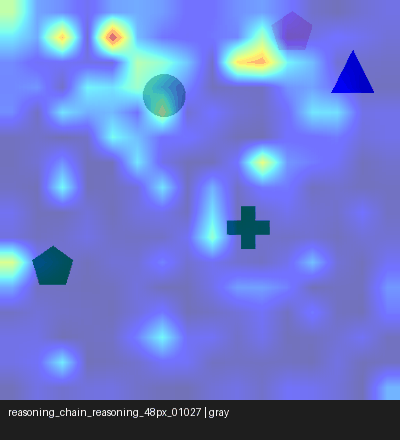

In [10]:
import io, base64
from IPython.display import HTML, display

def make_attention_gif_bytes(
    image: Image.Image,
    tokens: list,
    heatmaps: list,
    frame_size: tuple = (400, 400),
    caption_height: int = 40,
    fps: int = 3,
    alpha: float = 0.55,
    colormap: str = "jet",
    label: str = "",
) -> bytes:
    """Render per-token attention heatmaps into a GIF and return the bytes (no disk write)."""
    from PIL import ImageDraw as PILImageDraw

    duration_ms = int(1000 / fps)
    W, H        = frame_size
    total_H     = H + caption_height

    frames = []
    cumulative_text = ""
    for tok_str, hmap in zip(tokens, heatmaps):
        blended = overlay_attention(image.resize((W, H), Image.LANCZOS), hmap, alpha, colormap)

        frame = Image.new("RGB", (W, total_H), color=(30, 30, 30))
        frame.paste(blended, (0, 0))
        draw  = PILImageDraw.Draw(frame)

        cumulative_text += tok_str
        caption = f"{label} | {cumulative_text.strip()}" if label else cumulative_text.strip()
        draw.text((8, H + 6), caption, fill=(255, 255, 255))
        frames.append(frame)

    buf = io.BytesIO()
    frames[0].save(
        buf,
        format="GIF",
        save_all=True,
        append_images=frames[1:],
        loop=0,
        duration=duration_ms,
        optimize=False,
    )
    buf.seek(0)
    return buf.read()


def display_gif_inline(gif_bytes: bytes, width: int = 450):
    """Display a GIF inline in the notebook via base64-encoded HTML <img> tag."""
    b64 = base64.b64encode(gif_bytes).decode("utf-8")
    html = f'<img src="data:image/gif;base64,{b64}" width="{width}">'
    display(HTML(html))


print("In-memory GIF rendering functions defined ✓")

# ── Render and display each result ───────────────────────────────────────────
for name, res in results.items():
    print(f"\nQuestion : {QUESTION}")
    print(f"Image    : {name}")
    print(f"Answer   : {res['answer']!r}")
    print(f"Tokens   : {res['tokens']}")
    print(f"Generating GIF ({len(res['tokens'])} frames)...")

    gif_bytes = make_attention_gif_bytes(
        image=images[name],
        tokens=res["tokens"],
        heatmaps=res["heatmaps"],
        label=name,
    )
    print(f"  GIF size: {len(gif_bytes)/1024:.1f} KB  — displaying below")
    display_gif_inline(gif_bytes, width=450)

## 7. Static Grid: All Token Heatmaps Side by Side

Display all per-token attention heatmaps for each image in a single row for quick visual comparison.


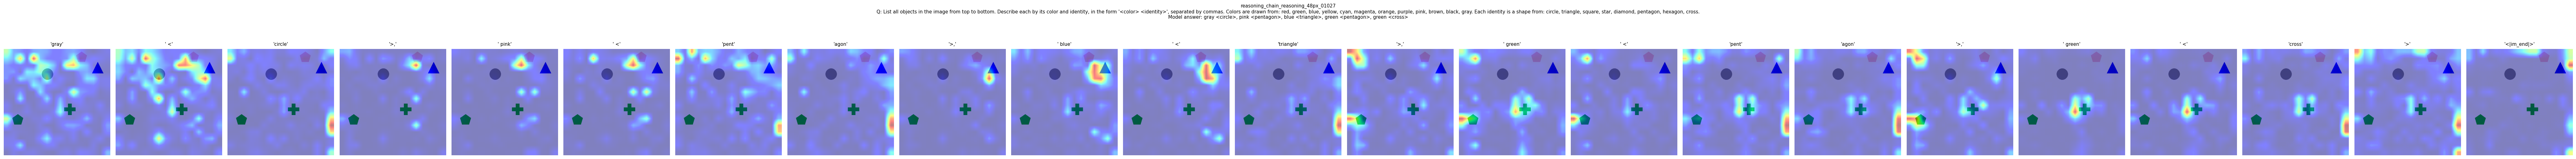

PDF saved → outputs/qwen3vl_rollout/attention_grid.pdf


In [11]:
import matplotlib.pyplot as plt
import io, base64
from IPython.display import HTML, display
from matplotlib.backends.backend_pdf import PdfPages

def fig_to_html(fig, dpi=100):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{b64}" style="max-width:100%">'

PDF_PATH = str(OUTPUT_DIR / "attention_grid.pdf")

with PdfPages(PDF_PATH) as pdf:
    for name, res in results.items():
        tokens   = res["tokens"]
        heatmaps = res["heatmaps"]
        n        = len(tokens)

        fig, axes = plt.subplots(1, n, figsize=(3 * n, 4.5))
        if n == 1:
            axes = [axes]

        img_rgb = np.array(images[name].convert("RGB"))

        for i, (tok, hmap) in enumerate(zip(tokens, heatmaps)):
            ax  = axes[i]
            hup = np.array(
                Image.fromarray((hmap * 255).astype(np.uint8)).resize(
                    images[name].size, Image.BILINEAR
                )
            ) / 255.0
            ax.imshow(img_rgb)
            ax.imshow(hup, cmap="jet", alpha=0.5, vmin=0, vmax=1)
            ax.set_title(repr(tok), fontsize=9, pad=6)
            ax.axis("off")

        fig.suptitle(
            f"{name}\nQ: {QUESTION}\nModel answer: {res['answer']}",
            fontsize=9,
            y=1.02,
        )
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        display(HTML(fig_to_html(fig, dpi=120)))
        plt.close(fig)

print(f"PDF saved → {PDF_PATH}")